In [7]:
# ============================================================
# Script 4.1 (Updated): Package imports untuk Qiskit 2.3.0
# ============================================================
# Perubahan utama:
# - 'from qiskit import *' sudah DEPRECATED, harus explicit import
# - qiskit-ibmq-provider sudah EOL, diganti qiskit_ibm_runtime
# - IBMQ.save_account() sudah tidak ada

import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as LA

# Qiskit 2.x: import explicit, bukan wildcard
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Operator, SparsePauliOp, Statevector

# Simulator lokal: BasicAer DIHAPUS di Qiskit 1.0+, gunakan qiskit_aer
from qiskit_aer import AerSimulator

# IBM Runtime (untuk akses IBM Quantum Cloud)
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

In [8]:
# ============================================================
# Script 4.2 (Bug-fixed): Hamiltonian dan Propagator
# ============================================================

J  = 1
h0 = -0.5
h1 =  0.5

X = np.array([[0, 1 ], [1,  0]], dtype=complex)
Y = np.array([[0,-1j], [1j, 0]], dtype=complex)  # FIX: tanda -1j di [0,1]
Z = np.array([[1, 0 ], [0, -1]], dtype=complex)
I = np.eye(2,             dtype=complex)

# Hamiltonian 4×4 untuk sistem 2 qubit
# np.kron = Kronecker product (tensor product ⊗)
# Analogi: np.kron(Z, I) artinya "Z bekerja di qubit-0, I (identitas) di qubit-1"
H = (0.5 * (h0 * np.kron(Z, I) + h1 * np.kron(I, Z))
     + (J / 4) * (np.kron(X, X) + np.kron(Y, Y) + np.kron(Z, Z)))

# Propagator: U = exp(-iH·τ), τ = 1 a.u.
# Analogi: seperti memutar state kuantum di ruang Hilbert selama waktu τ
U = LA.expm(-1j * H)

print("Hamiltonian H (4×4):")
print(np.round(H, 3))
print("\nPropagator U = exp(-iH):")
print(np.round(U, 3))

# Verifikasi: U harus unitary → U†U = I
assert np.allclose(U.conj().T @ U, np.eye(4), atol=1e-10), "U is not unitary!"
print("\nVerifikasi: U adalah unitary ✓")

Hamiltonian H (4×4):
[[ 0.25+0.j  0.  +0.j  0.  +0.j  0.  +0.j]
 [ 0.  +0.j -0.75+0.j  0.5 +0.j  0.  +0.j]
 [ 0.  +0.j  0.5 +0.j  0.25+0.j  0.  +0.j]
 [ 0.  +0.j  0.  +0.j  0.  +0.j  0.25+0.j]]

Propagator U = exp(-iH):
[[0.969-0.247j 0.   +0.j    0.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.623+0.633j 0.114-0.445j 0.   +0.j   ]
 [0.   +0.j    0.114-0.445j 0.85 -0.257j 0.   +0.j   ]
 [0.   +0.j    0.   +0.j    0.   +0.j    0.969-0.247j]]

Verifikasi: U adalah unitary ✓


In [9]:
# ============================================================
# Script 4.3: Classical propagation (benchmark)
# ============================================================

# State awal |00⟩ dalam representasi vektor: [1, 0, 0, 0]
# Urutan: |00⟩=index 0, |01⟩=index 1, |10⟩=index 2, |11⟩=index 3
psi_init = np.array([1, 0, 0, 0], dtype=complex)

# Propagasi klasik: |ψ(τ)⟩ = U|ψ(0)⟩
# Analogi: mengalikan matriks rotasi dengan vektor posisi
psi_fin = U @ psi_init

print("State awal  |ψ(0)⟩:", np.round(psi_init, 4))
print("State akhir |ψ(τ)⟩:", np.round(psi_fin, 4))
print("Probabilitas klasik:", np.round(np.abs(psi_fin)**2, 4))

State awal  |ψ(0)⟩: [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
State akhir |ψ(τ)⟩: [0.9689-0.2474j 0.    +0.j     0.    +0.j     0.    +0.j    ]
Probabilitas klasik: [1. 0. 0. 0.]


     ┌──────────┐┌─┐   
q_0: ┤0         ├┤M├───
     │  Unitary │└╥┘┌─┐
q_1: ┤1         ├─╫─┤M├
     └──────────┘ ║ └╥┘
c: 2/═════════════╩══╩═
                  0  1 


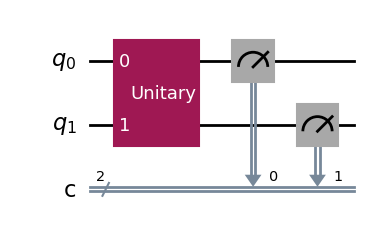

In [11]:
# ============================================================
# Scripts 4.4–4.6 (Updated): Quantum Circuit Setup
# ============================================================

# Membuat quantum circuit dengan 2 qubit
# Analogi: menyiapkan "panggung" dengan 2 aktor (qubit) dan 2 "buku catatan" (classical bits)
qreg = QuantumRegister(2, name='q')    # 2 qubit quantum
creg = ClassicalRegister(2, name='c') # 2 bit klasik untuk menyimpan hasil ukur
entangler = QuantumCircuit(qreg, creg)

# Karena initial state |00⟩ adalah default, tidak perlu initialize secara eksplisit

# Bungkus matriks propagator U sebagai quantum gate
# Operator() mengonversi numpy matrix → Qiskit gate
U_gate = Operator(U)

# Append gate ke circuit, berlaku untuk qubit 0 dan 1
# Analogi: memasang "mesin" di atas panggung yang akan mengoperasikan kedua aktor
entangler.append(U_gate, [0, 1])

# Tambahkan pengukuran di akhir circuit
# qubit 0 → classical bit 0, qubit 1 → classical bit 1
entangler.measure(0, 0)
entangler.measure(1, 1)

print(entangler.draw(output='text'))
entangler.draw('mpl')

In [ ]:
# ============================================================
# Scripts 4.7–4.9 (Updated): IBM Account & QASM Simulator
# ============================================================

# --- Cara menyimpan akun IBM (lakukan sekali) ---
QiskitRuntimeService.save_account(channel="ibm_quantum_platform",token="DbWShxxdMVLu2zzvDlspKP9kPLnJ8hHhMelBfP8ZerMU",overwrite=True)

# --- Menjalankan di LOKAL simulator (tanpa akun IBM) ---
# Ini padanan "QASM simulator" namun gratis & offline

# Qiskit 2.x: gunakan AerSimulator sebagai pengganti BasicAer
# AerSimulator mode 'statevector': simulasi deterministik tanpa noise
aer_sim = AerSimulator(method='statevector')

# Transpile: kompilasi circuit ke basis gates yang didukung simulator
# Analogi: seperti compile kode Python ke bytecode yang bisa dijalankan mesin
qc_transpiled = transpile(entangler, aer_sim)

# Jalankan circuit dengan 2000 shots
# "shots" = berapa kali eksperimen diulang untuk mendapat statistik
job = aer_sim.run(qc_transpiled, shots=2000)
result = job.result()
counts = result.get_counts()

# Konversi counts ke probabilitas
total_shots = sum(counts.values())
probs = {k: v/total_shots for k, v in counts.items()}

print("Hasil QASM Simulator (Aer):")
print("Counts:", counts)
print("Probabilitas:", {k: round(v, 4) for k, v in probs.items()})
print("Probabilitas klasik |00⟩:", round(np.abs(psi_fin[0])**2, 4))
print("Probabilitas klasik |11⟩:", round(np.abs(psi_fin[3])**2, 4))

Hasil QASM Simulator (Aer):
Counts: {'00': 2000}
Probabilitas: {'00': 1.0}
Probabilitas klasik |00⟩: 1.0
Probabilitas klasik |11⟩: 0.0


In [16]:
# ============================================================
# Script 4.10 (Fully Fixed): Menjalankan di IBM Real Machine
# qiskit_ibm_runtime >= 0.40
# ============================================================

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import numpy as np
import matplotlib.pyplot as plt

# --- LANGKAH 1: Koneksi ke service (sudah berhasil sebelumnya) ---
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print(f"Backend: {backend.name}")
print(f"Jumlah qubit: {backend.num_qubits}")
print(f"Basis gates: {backend.basis_gates}")

# --- LANGKAH 2: Rebuild circuit entangler ---
# (pastikan circuit sudah didefinisikan dengan benar dari Script 4.4-4.6)
import scipy.linalg as LA
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Operator

J=1; h0=-0.5; h1=0.5
X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex)
Z=np.array([[1,0],[0,-1]],dtype=complex)
I=np.eye(2,dtype=complex)

H_mat = (0.5*(h0*np.kron(Z,I) + h1*np.kron(I,Z))
         + (J/4)*(np.kron(X,X) + np.kron(Y,Y) + np.kron(Z,Z)))
U     = LA.expm(-1j * H_mat)

# Circuit dengan register bernama (penting untuk akses hasil di V2)
qreg     = QuantumRegister(2, name='q')
creg     = ClassicalRegister(2, name='c')   # nama 'c' akan dipakai saat akses hasil
entangler = QuantumCircuit(qreg, creg)
entangler.append(Operator(U), [0, 1])
entangler.measure(0, 0)
entangler.measure(1, 1)

print("\nCircuit sebelum transpile:")
print(entangler.draw(output='text'))
print(f"Depth sebelum transpile: {entangler.depth()}")

# --- LANGKAH 3: Transpile ke ISA (Instruction Set Architecture) backend ---
# generate_preset_pass_manager adalah cara RESMI dan WAJIB untuk hardware IBM
# Ini menerjemahkan circuit ke basis gates hardware (CNOT, RZ, SX, X, ...)
# optimization_level: 0 (cepat, kurang optimal) s.d. 3 (lambat, paling optimal)
# Untuk eksperimen sederhana, level 1 sudah cukup

pm          = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(entangler)  # circuit yang siap dikirim ke hardware

print(f"\nCircuit setelah transpile (ISA):")
print(isa_circuit.draw(output='text', fold=80))
print(f"Depth setelah transpile: {isa_circuit.depth()}")
print(f"Basis gates yang digunakan: {set(isa_circuit.count_ops().keys())}")

Backend: ibm_fez
Jumlah qubit: 156
Basis gates: ['cz', 'id', 'rz', 'sx', 'x']

Circuit sebelum transpile:
     ┌──────────┐┌─┐   
q_0: ┤0         ├┤M├───
     │  Unitary │└╥┘┌─┐
q_1: ┤1         ├─╫─┤M├
     └──────────┘ ║ └╥┘
c: 2/═════════════╩══╩═
                  0  1 
Depth sebelum transpile: 2

Circuit setelah transpile (ISA):
global phase: 7π/4
         ┌───┐ ┌────────────┐   ┌─────────┐ ┌────┐┌─────────────┐┌────┐»
q_0 -> 0 ┤ X ├─┤ Rz(1.0273) ├─■─┤ Rz(π/2) ├─┤ √X ├┤ Rz(-2.6643) ├┤ √X ├»
         ├───┴┐└┬──────────┬┘ │ ├─────────┴┐├────┤└─┬──────────┬┘└────┘»
q_1 -> 1 ┤ √X ├─┤ Rz(-π/2) ├──■─┤ Rz(-π/2) ├┤ √X ├──┤ Rz(-0.5) ├───────»
         └────┘ └──────────┘    └──────────┘└────┘  └──────────┘       »
    c: 2/══════════════════════════════════════════════════════════════»
                                                                       »
«         ┌─────────┐   ┌──────────┐┌────┐┌────────────┐┌────┐     ┌───┐   »
«q_0 -> 0 ┤ Rz(π/2) ├─■─┤ Rz(-π/2) ├┤ √X ├┤ Rz(2.6643) ├┤ 

In [ ]:
# --- LANGKAH 4: Jalankan di IBM hardware ---
# PERHATIAN Plan Open:
# Akun Open Plan IBM Quantum TIDAK mendukung Session mode (hanya job mode)
# Gunakan Sampler(mode=backend) langsung — ini adalah "job mode"

# FIX UTAMA: mode=backend, BUKAN backend=backend
sampler = Sampler(mode=backend)
sampler.options.default_shots = 2000

print(f"Submitting job ke {backend.name}...")
job = sampler.run([isa_circuit])

print(f"Job ID: {job.job_id()}")
print(f"Status: {job.status()}")
print("Job ter-submit! Tunggu hasilnya (bisa beberapa menit)...")

Submitting job ke ibm_fez...
Job ID: d7eq8br0g7hs73dtajr0
Status: QUEUED
Job ter-submit! Tunggu hasilnya (bisa beberapa menit)...


In [ ]:
# --- LANGKAH 5: Ambil dan proses hasil ---
# Gunakan job.job_id() untuk cek status nanti tanpa menunggu di notebook

# Cara 1: tunggu langsung (blok sampai selesai)
result      = job.result()
pub_result  = result[0]

# SamplerV2 V2: akses via .data.NAMA_REGISTER.get_counts()
# Nama register = 'c' sesuai ClassicalRegister(2, name='c') yang kita definisikan
counts_real = pub_result.data.c.get_counts()
total_shots  = sum(counts_real.values())

print(f"Raw counts: {counts_real}")

# Konversi ke probabilitas
# Catatan: Qiskit output little-endian — bit paling kanan = qubit index 0
# '00' = |q1=0, q0=0⟩ = |00⟩
# '11' = |q1=1, q0=1⟩ = |11⟩
probs_real = {k: v/total_shots for k, v in counts_real.items()}
print(f"Probabilitas (hardware): {probs_real}")

# Cara 2: cek job nanti via job ID (tidak perlu tunggu)
# job_saved = service.job("JOB_ID_KAMU")
# if job_saved.status() == "DONE":
#     counts = job_saved.result()[0].data.c.get_counts()

Raw counts: {'00': 1774, '11': 75, '10': 97, '01': 54}
Probabilitas (hardware): {'00': 0.887, '11': 0.0375, '10': 0.0485, '01': 0.027}


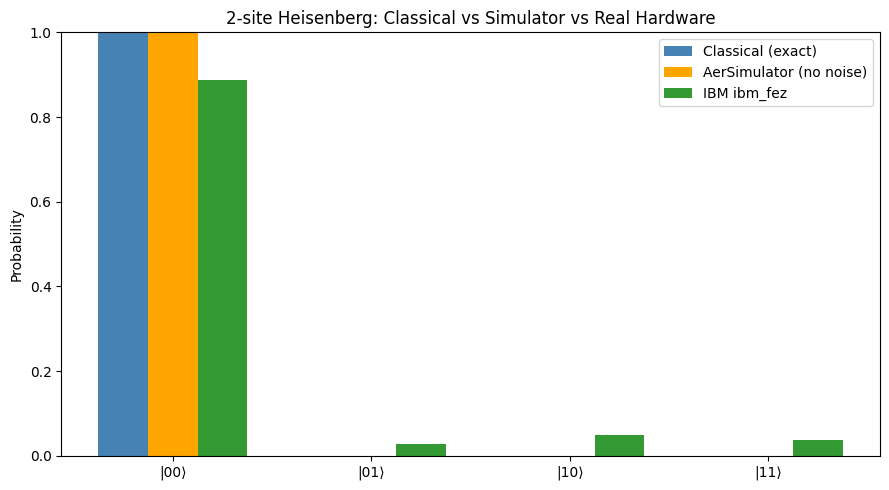


Fidelity hardware vs exact: 0.8870
(1.0 = sempurna, nilai turun karena noise hardware)


In [ ]:
# --- LANGKAH 6: Visualisasi lengkap (klasik + simulator + hardware) ---

# Classical benchmark
psi_init  = np.array([1,0,0,0], dtype=complex)
psi_fin   = U @ psi_init
classical_probs = np.abs(psi_fin)**2

# Simulator AerSimulator (kita sudah punya dari sebelumnya)
from qiskit_aer import AerSimulator
from qiskit import transpile

aer_sim      = AerSimulator(method='statevector')
qc_aer       = transpile(entangler, aer_sim)
aer_result   = aer_sim.run(qc_aer, shots=2000).result()
counts_aer   = aer_result.get_counts()
probs_aer    = {k: v/2000 for k, v in counts_aer.items()}

# Siapkan array untuk plotting
labels   = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
keys_bin = ['00', '01', '10', '11']

# Konversi: Qiskit output bisa tidak mengikutkan state dengan count 0
def get_prob(probs_dict, key, total=1):
    return probs_dict.get(key, 0)

sim_arr  = [get_prob(probs_aer,  k) for k in keys_bin]
real_arr = [get_prob(probs_real, k) for k in keys_bin]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(4)
ax.bar(x-0.25, classical_probs, 0.25, label='Classical (exact)',     color='steelblue')
ax.bar(x,      sim_arr,         0.25, label='AerSimulator (no noise)', color='orange')
ax.bar(x+0.25, real_arr,        0.25, label=f'IBM {backend.name}',    color='green', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Probability'); ax.set_ylim(0, 1)
ax.set_title('2-site Heisenberg: Classical vs Simulator vs Real Hardware')
ax.legend(); plt.tight_layout(); plt.show()

# Fidelity hardware vs exact
fidelity = sum(np.sqrt(classical_probs[i] * real_arr[i]) for i in range(4))**2
print(f"\nFidelity hardware vs exact: {fidelity:.4f}")
print("(1.0 = sempurna, nilai turun karena noise hardware)")
